<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_11_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 11 — DenseNet121 Lung Nodule Classification

This notebook trains and evaluates DenseNet121 for binary classification of lung nodules as benign or malignant.

The notebook follows the same patient-level dataset split, preprocessing pipeline, augmentation, class weights, evaluation metrics and validation-based threshold-selection procedure used for EfficientNetB0.

Two controlled experiments are performed:

1. Frozen DenseNet121 backbone with a trainable classification head.
2. Fine-tuning of the final 30 DenseNet121 backbone layers.

The test set remains untouched until the better DenseNet121 configuration has been selected using validation PR-AUC.

##2. Imports

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.applications.densenet import (
    preprocess_input as densenet_preprocess
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# ============================================================
# Serializable DenseNet121 Preprocessing Layer
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class DenseNetPreprocessing(
    tf.keras.layers.Layer
):

    def call(self, inputs):
        return (
            tf.keras.applications.densenet
            .preprocess_input(inputs)
        )

    def get_config(self):
        return super().get_config()

##3. Mount Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 4. Project Paths and Output Directories

In [ ]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

PROCESSED_PATH = (
    DRIVE_ROOT /
    "Dataset" /
    "Processed"
)

MODEL_PATH = (
    DRIVE_ROOT /
    "Models"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = PROCESSED_PATH / "train.csv"
VALIDATION_CSV = PROCESSED_PATH / "validation.csv"
TEST_CSV = PROCESSED_PATH / "test.csv"

##5. Load Dataset

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)

validation_df = pd.read_csv(VALIDATION_CSV)

test_df = pd.read_csv(TEST_CSV)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(1149, 5)
(237, 5)
(256, 5)


##6. Global Configuration

In [ ]:
IMAGE_SIZE = (128, 128)

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

SEED = 42

tf.random.set_seed(SEED)

np.random.seed(SEED)

##7. Compute Class Weights

In [ ]:
classes = np.unique(train_df["CancerLabel"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["CancerLabel"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5699404761904762), np.int64(1): np.float64(4.074468085106383)}


##8. Image Loading Function

In [ ]:
def load_image(path, label):
    """
    Load an RGB PNG for EfficientNet.

    Important:
    EfficientNetB0 includes internal rescaling and expects
    float32 pixel values in the range 0–255.
    """

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    # Keep the original 0–255 scale.
    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="area"
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

####8.1. Data Augmentation

In [ ]:
# ============================================================
# Data Augmentation
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(
                IMAGE_SIZE[0],
                IMAGE_SIZE[1],
                3
            )
        ),

        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),

        tf.keras.layers.RandomRotation(
            factor=0.05
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        )
    ],
    name="data_augmentation"
)

print(
    "Augmentation input shape:",
    data_augmentation.input_shape
)

print(
    "Augmentation output shape:",
    data_augmentation.output_shape
)

Augmentation input shape: (None, 128, 128, 3)
Augmentation output shape: (None, 128, 128, 3)


####8.2 Dataset Builder



In [ ]:
# ============================================================
# Build TensorFlow Dataset
# ============================================================

def build_dataset(df, training=False):

    paths = df["ImagePath"].values
    labels = df["CancerLabel"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    # Shuffle training samples before loading/batching.
    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

In [ ]:
train_ds = build_dataset(
    train_df,
    training=True
)

validation_ds = build_dataset(
    validation_df,
    training=False
)

test_ds = build_dataset(
    test_df,
    training=False
)

## 9. Experiment 1 — Frozen DenseNet121 Baseline

DenseNet121 is initialised with ImageNet-pretrained weights. During the baseline experiment, the convolutional backbone remains frozen and only the custom binary classification head is trained.

This experiment establishes a DenseNet121 transfer-learning baseline under the same dataset and evaluation protocol used for EfficientNetB0.

## 10. Build DenseNet121 Backbone

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import (
    preprocess_input as densenet_preprocess
)

print("IMAGE_SIZE:", IMAGE_SIZE)
print("IMAGE_SIZE type:", type(IMAGE_SIZE))

densenet_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    )
)

densenet_base.trainable = False

print("Backbone:", densenet_base.name)
print("Backbone layers:", len(densenet_base.layers))
print("Backbone input shape:", densenet_base.input_shape)

IMAGE_SIZE: (128, 128)
IMAGE_SIZE type: <class 'tuple'>
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone: densenet121
Backbone layers: 427
Backbone input shape: (None, 128, 128, 3)


## 11. Build DenseNet121 Classification Model

In [ ]:
# ============================================================
# Build DenseNet121 Classification Model
# ============================================================

inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    ),
    name="input_image"
)

# Automatically active during training and inactive during
# validation, evaluation and prediction.
x = data_augmentation(inputs)

# DenseNet121 preprocessing expects float32 RGB images
# whose values remain in the original 0–255 range.
x = DenseNetPreprocessing(
    name="densenet_preprocessing"
)(x)

x = densenet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
    name="binary_output"
)(x)

densenet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="DenseNet121_LungNoduleClassifier"
)

print(
    "Model input shape:",
    densenet_model.input_shape
)

print(
    "Model output shape:",
    densenet_model.output_shape
)

print(
    "DenseNet backbone trainable:",
    densenet_base.trainable
)

Model input shape: (None, 128, 128, 3)
Model output shape: (None, 1)
DenseNet backbone trainable: False


## 12. Model Summary

In [ ]:
densenet_model.summary()

print(
    "Backbone trainable:",
    densenet_base.trainable
)

print(
    "Total parameters:",
    densenet_model.count_params()
)

Model: "DenseNet121_LungNoduleClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocessing          │ (None, 128, 128, 3)    │             0 │
│ (DenseNetPreprocessing)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Backbone trainable: False
Total parameters: 7038529


## 13. Compile Frozen-Backbone Model

In [ ]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

## 14. Define Baseline Output Paths

In [ ]:
DENSENET_RUN_NAME = "Corrected_Run_01"

DENSENET_ROOT = (
    MODEL_PATH
    / "DenseNet121"
    / DENSENET_RUN_NAME
)

DENSENET_BASELINE_DIR = (
    DENSENET_ROOT
    / "Baseline"
)

DENSENET_BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DENSENET_BASELINE_BEST = (
    DENSENET_BASELINE_DIR
    / "best_model.keras"
)

DENSENET_BASELINE_FINAL = (
    DENSENET_BASELINE_DIR
    / "final_model.keras"
)

DENSENET_BASELINE_HISTORY = (
    DENSENET_BASELINE_DIR
    / "training_history.csv"
)

DENSENET_BASELINE_LOG_DIR = (
    DENSENET_BASELINE_DIR
    / "logs"
)

DENSENET_BASELINE_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(DENSENET_BASELINE_DIR)

/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline


## 15. Define Baseline Callbacks

In [ ]:
densenet_baseline_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            DENSENET_BASELINE_BEST
        ),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=7,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        str(
            DENSENET_BASELINE_HISTORY
        ),
        append=False
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=str(
            DENSENET_BASELINE_LOG_DIR
        )
    )
]

## 16. Train Frozen-Backbone Baseline

In [ ]:
DENSENET_BASELINE_EPOCHS = 30

densenet_baseline_history = (
    densenet_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=DENSENET_BASELINE_EPOCHS,
        class_weight=class_weights,
        callbacks=densenet_baseline_callbacks,
        verbose=1
    )
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6142 - auc: 0.5229 - loss: 0.9547 - pr_auc: 0.1565 - precision: 0.1708 - recall: 0.4280
Epoch 1: val_pr_auc improved from None to 0.32185, saving model to /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.5831 - auc: 0.5359 - loss: 0.8584 - pr_auc: 0.1396 - precision: 0.1435 - recall: 0.4823 - val_accuracy: 0.5527 - val_auc: 0.6224 - val_loss: 0.7420 - val_pr_auc: 0.3219 - val_precision: 0.1579 - val_recall: 0.6429 - learning_rate: 1.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6361 - auc: 0.6392 - loss: 0.6990 - pr_auc: 0.1841 - precision: 0.1752 - recall: 0.6115
Epoch 2: val_pr_auc improved from 0.32185 to 0.34735, saving model to /content/drive/MyDrive/Dissertatio

## 17. Save Baseline Training Outputs

In [ ]:
densenet_model.save(
    DENSENET_BASELINE_FINAL
)

densenet_baseline_history_df = (
    pd.DataFrame(
        densenet_baseline_history.history
    )
)

densenet_baseline_history_df.to_csv(
    DENSENET_BASELINE_HISTORY,
    index=False
)

print(
    "Saved baseline final model:",
    DENSENET_BASELINE_FINAL
)

print(
    "Saved baseline history:",
    DENSENET_BASELINE_HISTORY
)

Saved baseline final model: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/final_model.keras
Saved baseline history: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/training_history.csv


## 18. Plot Baseline Learning Curves

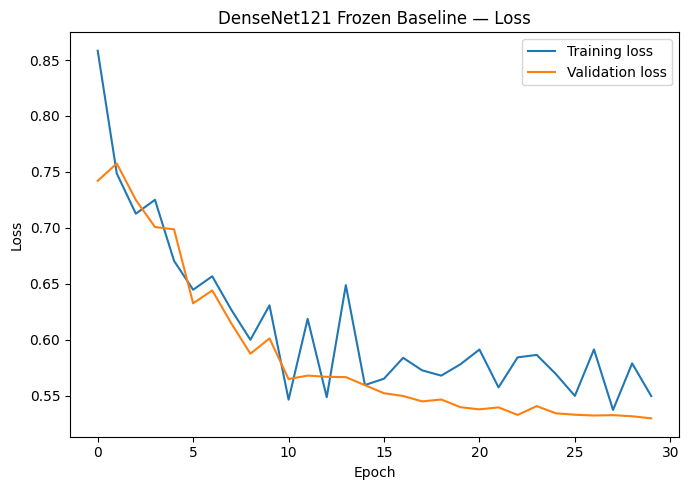

In [ ]:
history_df = pd.DataFrame(
    densenet_baseline_history.history
)

plt.figure(figsize=(7, 5))

plt.plot(
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Frozen Baseline — Loss")
plt.legend()
plt.tight_layout()
plt.show()

###ROC-AUC

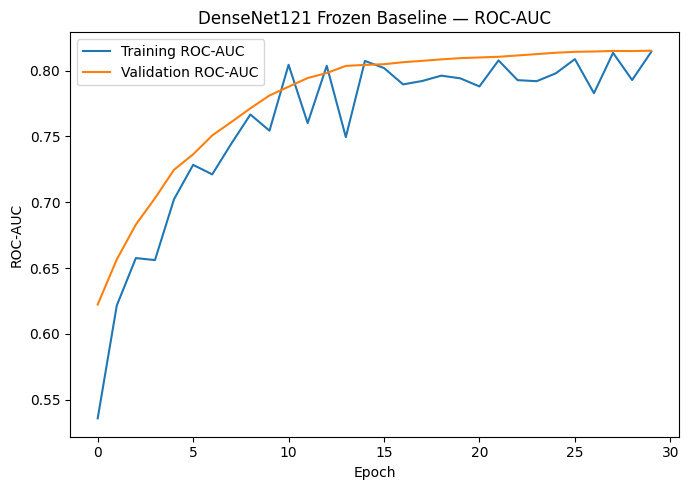

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_df["auc"],
    label="Training ROC-AUC"
)

plt.plot(
    history_df["val_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title(
    "DenseNet121 Frozen Baseline — ROC-AUC"
)
plt.legend()
plt.tight_layout()
plt.show()

###PR-AUC

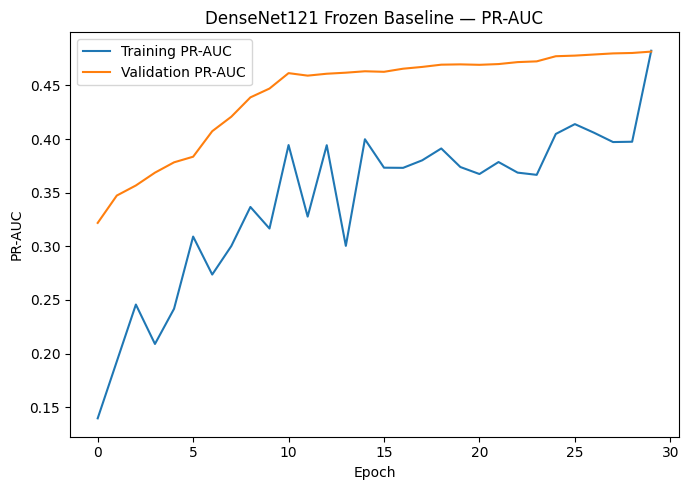

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_df["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    history_df["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title(
    "DenseNet121 Frozen Baseline — PR-AUC"
)
plt.legend()
plt.tight_layout()
plt.show()

## 19. Load Best DenseNet121 Baseline Checkpoint

In [ ]:
# ============================================================
# Load Best DenseNet121 Baseline Checkpoint
# ============================================================

DENSENET_BASELINE_DIR = (
    DENSENET_ROOT
    / "Baseline"
)

DENSENET_BASELINE_BEST = (
    DENSENET_BASELINE_DIR
    / "best_model.keras"
)

densenet_baseline_model = tf.keras.models.load_model(
    DENSENET_BASELINE_BEST,
    custom_objects={
        "preprocess_input": densenet_preprocess
    },
    compile=False
)

print("Loaded DenseNet121 baseline:")
print(DENSENET_BASELINE_BEST)

print("Model name:", densenet_baseline_model.name)
print("Input shape:", densenet_baseline_model.input_shape)
print("Output shape:", densenet_baseline_model.output_shape)

NameError: name 'DENSENET_ROOT' is not defined

## 20. Evaluate DenseNet121 Baseline on Validation Set

In [ ]:
y_val = np.concatenate([
    labels.numpy().reshape(-1)
    for _, labels in validation_ds
])

###Predict

In [ ]:
y_val_prob_densenet_baseline = (
    densenet_baseline_model.predict(
        validation_ds,
        verbose=1
    ).reshape(-1)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step


###Metrics

In [ ]:
densenet_baseline_val_roc_auc = (
    roc_auc_score(
        y_val,
        y_val_prob_densenet_baseline
    )
)

densenet_baseline_val_pr_auc = (
    average_precision_score(
        y_val,
        y_val_prob_densenet_baseline
    )
)

print(
    "Validation ROC-AUC:",
    densenet_baseline_val_roc_auc
)

print(
    "Validation PR-AUC:",
    densenet_baseline_val_pr_auc
)

print(
    "Prediction minimum:",
    y_val_prob_densenet_baseline.min()
)

print(
    "Prediction maximum:",
    y_val_prob_densenet_baseline.max()
)

print(
    "Prediction mean:",
    y_val_prob_densenet_baseline.mean()
)

Validation ROC-AUC: 0.814935064935065
Validation PR-AUC: 0.4890872636325835
Prediction minimum: 0.036720894
Prediction maximum: 0.9759269
Prediction mean: 0.3959503


## 21. Select DenseNet121 Baseline Validation Thresholds

In [ ]:
(
    precision_densenet_baseline,
    recall_densenet_baseline,
    thresholds_densenet_baseline
) = precision_recall_curve(
    y_val,
    y_val_prob_densenet_baseline
)

f1_densenet_baseline = (
    2
    * precision_densenet_baseline
    * recall_densenet_baseline
    / (
        precision_densenet_baseline
        + recall_densenet_baseline
        + 1e-8
    )
)

densenet_baseline_best_index = (
    np.argmax(
        f1_densenet_baseline[:-1]
    )
)

densenet_baseline_f1_threshold = (
    thresholds_densenet_baseline[
        densenet_baseline_best_index
    ]
)

print(
    "Baseline F1 threshold:",
    densenet_baseline_f1_threshold
)

print(
    "Precision:",
    precision_densenet_baseline[
        densenet_baseline_best_index
    ]
)

print(
    "Recall:",
    recall_densenet_baseline[
        densenet_baseline_best_index
    ]
)

print(
    "F1:",
    f1_densenet_baseline[
        densenet_baseline_best_index
    ]
)

Baseline F1 threshold: 0.64965755
Precision: 0.425
Recall: 0.6071428571428571
F1: 0.4999999951557094


###Generate Validation Report

In [ ]:
y_val_pred_densenet_baseline = (
    y_val_prob_densenet_baseline
    >= densenet_baseline_f1_threshold
).astype(np.int32)

print(
    confusion_matrix(
        y_val,
        y_val_pred_densenet_baseline
    )
)

print(
    classification_report(
        y_val,
        y_val_pred_densenet_baseline,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4,
        zero_division=0
    )
)

[[186  23]
 [ 11  17]]
              precision    recall  f1-score   support

      Benign     0.9442    0.8900    0.9163       209
   Malignant     0.4250    0.6071    0.5000        28

    accuracy                         0.8565       237
   macro avg     0.6846    0.7485    0.7081       237
weighted avg     0.8828    0.8565    0.8671       237



###High-recall threshold

In [ ]:
TARGET_RECALL = 0.70

valid_indices = np.where(
    recall_densenet_baseline[:-1]
    >= TARGET_RECALL
)[0]

if len(valid_indices) > 0:

    densenet_baseline_high_recall_index = (
        valid_indices[
            np.argmax(
                precision_densenet_baseline[
                    valid_indices
                ]
            )
        ]
    )

    densenet_baseline_high_recall_threshold = (
        thresholds_densenet_baseline[
            densenet_baseline_high_recall_index
        ]
    )

    print(
        "High-recall threshold:",
        densenet_baseline_high_recall_threshold
    )

    print(
        "Precision:",
        precision_densenet_baseline[
            densenet_baseline_high_recall_index
        ]
    )

    print(
        "Recall:",
        recall_densenet_baseline[
            densenet_baseline_high_recall_index
        ]
    )

else:
    densenet_baseline_high_recall_threshold = None

    print(
        "No threshold reached target recall."
    )

High-recall threshold: 0.46830612
Precision: 0.25925925925925924
Recall: 0.75


###Reload Baseline Model without Training

In [ ]:
@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class DenseNetPreprocessing(tf.keras.layers.Layer):

    def call(self, inputs):
        return (
            tf.keras.applications.densenet
            .preprocess_input(inputs)
        )

    def get_config(self):
        return super().get_config()

In [ ]:
DENSENET_RUN_NAME = "Corrected_Run_01"

DENSENET_ROOT = (
    MODEL_PATH
    / "DenseNet121"
    / DENSENET_RUN_NAME
)

DENSENET_BASELINE_DIR = (
    DENSENET_ROOT
    / "Baseline"
)

DENSENET_BASELINE_BEST = (
    DENSENET_BASELINE_DIR
    / "best_model.keras"
)

DENSENET_BASELINE_FINAL = (
    DENSENET_BASELINE_DIR
    / "final_model.keras"
)

DENSENET_BASELINE_HISTORY = (
    DENSENET_BASELINE_DIR
    / "training_history.csv"
)

DENSENET_BASELINE_LOG_DIR = (
    DENSENET_BASELINE_DIR
    / "logs"
)

In [ ]:
densenet_baseline_model = tf.keras.models.load_model(
    DENSENET_BASELINE_BEST,
    custom_objects={
        "DenseNetPreprocessing": DenseNetPreprocessing
    },
    compile=False
)

print("Loaded checkpoint:")
print(DENSENET_BASELINE_BEST)

print("Model:", densenet_baseline_model.name)
print("Input:", densenet_baseline_model.input_shape)
print("Output:", densenet_baseline_model.output_shape)

Loaded checkpoint:
/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/best_model.keras
Model: DenseNet121_LungNoduleClassifier
Input: (None, 128, 128, 3)
Output: (None, 1)


In [ ]:
sample_images, sample_labels = next(
    iter(validation_ds)
)

sample_probabilities = (
    densenet_baseline_model.predict(
        sample_images,
        verbose=0
    )
)

print(
    "Prediction shape:",
    sample_probabilities.shape
)

print(
    "Probability range:",
    float(sample_probabilities.min()),
    "to",
    float(sample_probabilities.max())
)

Prediction shape: (16, 1)
Probability range: 0.13421344757080078 to 0.8933643102645874


## 22. Experiment 2 — Fine-Tune the Final 30 DenseNet121 Layers

The best frozen-backbone DenseNet121 checkpoint is used as the starting point for fine-tuning.

All DenseNet121 backbone layers are initially frozen. The final 30 backbone layers are then made trainable, while BatchNormalization layers remain frozen. This allows higher-level DenseNet features to adapt to lung nodule morphology while reducing the risk of unstable training and catastrophic forgetting.

The model is recompiled using Adam with a lower learning rate of `1e-5`. The loss function, class weights, augmentation and dataset splits remain unchanged so that this experiment is directly comparable with the frozen-backbone baseline.

The fine-tuned model will be selected using validation PR-AUC. The test set will remain untouched until the better DenseNet121 configuration has been selected.

## 23. Load the Best DenseNet121 Baseline for Fine-Tuning

In [ ]:
densenet_fine_tune_model = tf.keras.models.load_model(
    DENSENET_BASELINE_BEST,
    custom_objects={
        "DenseNetPreprocessing": DenseNetPreprocessing
    },
    compile=False
)

print("Loaded baseline checkpoint for fine-tuning:")
print(DENSENET_BASELINE_BEST)

print(
    "Fine-tuning model:",
    densenet_fine_tune_model.name
)

Loaded baseline checkpoint for fine-tuning:
/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/best_model.keras
Fine-tuning model: DenseNet121_LungNoduleClassifier


## 24. Locate the DenseNet121 Backbone

In [ ]:
densenet_backbones = [
    layer
    for layer in densenet_fine_tune_model.layers
    if (
        isinstance(layer, tf.keras.Model)
        and "densenet" in layer.name.lower()
    )
]

if len(densenet_backbones) != 1:
    raise ValueError(
        "Expected exactly one DenseNet backbone, "
        f"but found {len(densenet_backbones)}."
    )

densenet_fine_tune_base = (
    densenet_backbones[0]
)

print(
    "Located backbone:",
    densenet_fine_tune_base.name
)

print(
    "Backbone layers:",
    len(densenet_fine_tune_base.layers)
)

Located backbone: densenet121
Backbone layers: 427


## 25. Configure the Final 30 Backbone Layers

In [ ]:
# First freeze the complete backbone.
densenet_fine_tune_base.trainable = True

for layer in densenet_fine_tune_base.layers:
    layer.trainable = False

# Unfreeze the final 30 backbone layers.
for layer in densenet_fine_tune_base.layers[-30:]:
    layer.trainable = True

# Keep all BatchNormalization layers frozen.
for layer in densenet_fine_tune_base.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

## 26. Verify the Fine-Tuning Configuration

In [ ]:
trainable_backbone_layers = [
    layer
    for layer in densenet_fine_tune_base.layers
    if layer.trainable
]

frozen_backbone_layers = [
    layer
    for layer in densenet_fine_tune_base.layers
    if not layer.trainable
]

print(
    "Total backbone layers:",
    len(densenet_fine_tune_base.layers)
)

print(
    "Trainable backbone layers:",
    len(trainable_backbone_layers)
)

print(
    "Frozen backbone layers:",
    len(frozen_backbone_layers)
)

print("\nTrainable backbone layer names:")

for layer in trainable_backbone_layers:
    print(
        layer.name,
        "—",
        layer.__class__.__name__
    )

Total backbone layers: 427
Trainable backbone layers: 21
Frozen backbone layers: 406

Trainable backbone layer names:
conv5_block13_0_relu — Activation
conv5_block13_1_conv — Conv2D
conv5_block13_1_relu — Activation
conv5_block13_2_conv — Conv2D
conv5_block13_concat — Concatenate
conv5_block14_0_relu — Activation
conv5_block14_1_conv — Conv2D
conv5_block14_1_relu — Activation
conv5_block14_2_conv — Conv2D
conv5_block14_concat — Concatenate
conv5_block15_0_relu — Activation
conv5_block15_1_conv — Conv2D
conv5_block15_1_relu — Activation
conv5_block15_2_conv — Conv2D
conv5_block15_concat — Concatenate
conv5_block16_0_relu — Activation
conv5_block16_1_conv — Conv2D
conv5_block16_1_relu — Activation
conv5_block16_2_conv — Conv2D
conv5_block16_concat — Concatenate
relu — Activation


In [ ]:
trainable_batch_norm_layers = [
    layer.name
    for layer in densenet_fine_tune_base.layers
    if (
        isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        )
        and layer.trainable
    )
]

print(
    "Trainable BatchNormalization layers:",
    trainable_batch_norm_layers
)

assert len(
    trainable_batch_norm_layers
) == 0

Trainable BatchNormalization layers: []


In [ ]:
trainable_parameters = int(
    np.sum([
        np.prod(variable.shape)
        for variable
        in densenet_fine_tune_model.trainable_weights
    ])
)

non_trainable_parameters = int(
    np.sum([
        np.prod(variable.shape)
        for variable
        in densenet_fine_tune_model.non_trainable_weights
    ])
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_parameters:,}"
)

Trainable parameters: 631,809
Non-trainable parameters: 6,406,720


## 27. Recompile the DenseNet121 Fine-Tuning Model

In [ ]:
densenet_fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print(
    "Fine-tuning model compiled "
    "with learning rate 1e-5."
)

Fine-tuning model compiled with learning rate 1e-5.


## 28. Define Fine-Tuning Output Paths

In [ ]:
DENSENET_FINE_TUNE_DIR = (
    DENSENET_ROOT
    / "FineTune_Last30"
)

DENSENET_FINE_TUNE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DENSENET_FINE_TUNE_BEST = (
    DENSENET_FINE_TUNE_DIR
    / "best_model.keras"
)

DENSENET_FINE_TUNE_FINAL = (
    DENSENET_FINE_TUNE_DIR
    / "final_model.keras"
)

DENSENET_FINE_TUNE_HISTORY = (
    DENSENET_FINE_TUNE_DIR
    / "training_history.csv"
)

DENSENET_FINE_TUNE_LOG_DIR = (
    DENSENET_FINE_TUNE_DIR
    / "logs"
)

DENSENET_FINE_TUNE_BACKUP_DIR = (
    DENSENET_FINE_TUNE_DIR
    / "training_backup"
)

DENSENET_FINE_TUNE_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Fine-tuning directory:",
    DENSENET_FINE_TUNE_DIR
)

Fine-tuning directory: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30


## 29. Define Fine-Tuning Callbacks

In [ ]:
densenet_fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            DENSENET_FINE_TUNE_BEST
        ),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=7,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(
            DENSENET_FINE_TUNE_HISTORY
        ),
        append=True
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=str(
            DENSENET_FINE_TUNE_LOG_DIR
        )
    ),

    tf.keras.callbacks.BackupAndRestore(
        backup_dir=str(
            DENSENET_FINE_TUNE_BACKUP_DIR
        ),
        save_freq="epoch",
        delete_checkpoint=False
    )
]

## 30. Fine-Tune the Final 30 DenseNet121 Layers

In [ ]:
DENSENET_FINE_TUNE_EPOCHS = 20

densenet_fine_tune_history = (
    densenet_fine_tune_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=DENSENET_FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=densenet_fine_tune_callbacks,
        verbose=1
    )
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7299 - auc: 0.8098 - loss: 0.5872 - pr_auc: 0.4485 - precision: 0.3050 - recall: 0.6996
Epoch 1: val_pr_auc improved from None to 0.50401, saving model to /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.7224 - auc: 0.7990 - loss: 0.5697 - pr_auc: 0.3875 - precision: 0.2633 - recall: 0.7021 - val_accuracy: 0.7553 - val_auc: 0.8239 - val_loss: 0.4817 - val_pr_auc: 0.5040 - val_precision: 0.2794 - val_recall: 0.6786 - learning_rate: 1.0000e-05
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7800 - auc: 0.8317 - loss: 0.4997 - pr_auc: 0.4240 - precision: 0.2901 - recall: 0.6873
Epoch 2: val_pr_auc improved from 0.50401 to 0.50598, saving model to /content/drive/MyD

## 31. Save Fine-Tuning Outputs

In [ ]:
densenet_fine_tune_model.save(
    DENSENET_FINE_TUNE_FINAL
)

fine_tune_history_df = pd.DataFrame(
    densenet_fine_tune_history.history
)

if DENSENET_FINE_TUNE_HISTORY.exists():
    saved_history_df = pd.read_csv(
        DENSENET_FINE_TUNE_HISTORY
    )

    saved_history_df = (
        saved_history_df
        .drop_duplicates(
            subset=["epoch"],
            keep="last"
        )
        .sort_values("epoch")
    )

    saved_history_df.to_csv(
        DENSENET_FINE_TUNE_HISTORY,
        index=False
    )

print(
    "Saved fine-tuned final model:",
    DENSENET_FINE_TUNE_FINAL
)

print(
    "Saved fine-tuning history:",
    DENSENET_FINE_TUNE_HISTORY
)

Saved fine-tuned final model: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/final_model.keras
Saved fine-tuning history: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/training_history.csv


##32. Restore paths after reconnection

In [ ]:
from pathlib import Path

DENSENET_ROOT = Path(
    "/content/drive/MyDrive/Dissertation/Models/"
    "DenseNet121/Corrected_Run_01"
)

DENSENET_BASELINE_DIR = (
    DENSENET_ROOT / "Baseline"
)

DENSENET_FINE_TUNE_DIR = (
    DENSENET_ROOT / "FineTune_Last30"
)

DENSENET_BASELINE_BEST = (
    DENSENET_BASELINE_DIR / "best_model.keras"
)

DENSENET_FINE_TUNE_BEST = (
    DENSENET_FINE_TUNE_DIR / "best_model.keras"
)

DENSENET_FINE_TUNE_FINAL = (
    DENSENET_FINE_TUNE_DIR / "final_model.keras"
)

print("Baseline checkpoint exists:",
      DENSENET_BASELINE_BEST.exists())

print("Fine-tuned best exists:",
      DENSENET_FINE_TUNE_BEST.exists())

print("Fine-tuned final exists:",
      DENSENET_FINE_TUNE_FINAL.exists())

Baseline checkpoint exists: True
Fine-tuned best exists: True
Fine-tuned final exists: True


##33. Define the preprocessing layer before loading

In [ ]:
@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class DenseNetPreprocessing(
    tf.keras.layers.Layer
):

    def call(self, inputs):

        return (
            tf.keras.applications.densenet
            .preprocess_input(inputs)
        )

    def get_config(self):

        return super().get_config()

##34. Reload the best fine-tuned model

In [ ]:
densenet_fine_tuned_best = (
    tf.keras.models.load_model(
        DENSENET_FINE_TUNE_BEST,
        custom_objects={
            "DenseNetPreprocessing":
                DenseNetPreprocessing,

            "LungNoduleClassification>"
            "DenseNetPreprocessing":
                DenseNetPreprocessing
        },
        compile=False
    )
)

print("Loaded best fine-tuned DenseNet121:")
print(DENSENET_FINE_TUNE_BEST)

print(
    "Model name:",
    densenet_fine_tuned_best.name
)

print(
    "Input shape:",
    densenet_fine_tuned_best.input_shape
)

print(
    "Output shape:",
    densenet_fine_tuned_best.output_shape
)

Loaded best fine-tuned DenseNet121:
/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras
Model name: DenseNet121_LungNoduleClassifier
Input shape: (None, 128, 128, 3)
Output shape: (None, 1)


##35. COnfirm the model works

In [ ]:
sample_images, sample_labels = next(
    iter(validation_ds)
)

sample_probabilities = (
    densenet_fine_tuned_best.predict(
        sample_images,
        verbose=0
    )
)

print(
    "Sample image shape:",
    sample_images.shape
)

print(
    "Prediction shape:",
    sample_probabilities.shape
)

print(
    "Minimum prediction:",
    float(sample_probabilities.min())
)

print(
    "Maximum prediction:",
    float(sample_probabilities.max())
)

Sample image shape: (16, 128, 128, 3)
Prediction shape: (16, 1)
Minimum prediction: 0.05078957602381706
Maximum prediction: 0.8773065805435181


##36. Generate fine-tuned validation

In [ ]:
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)

In [ ]:
#Collect the true labels#
validation_true = np.concatenate(
    [
        labels.numpy()
        for images, labels
        in validation_ds
    ]
).astype(int)

validation_prob_fine_tuned = (
    densenet_fine_tuned_best.predict(
        validation_ds,
        verbose=1
    )
    .ravel()
)

print(
    "Validation labels:",
    validation_true.shape
)

print(
    "Validation predictions:",
    validation_prob_fine_tuned.shape
)

print(
    "Positive validation cases:",
    validation_true.sum()
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step
Validation labels: (237,)
Validation predictions: (237,)
Positive validation cases: 28


##37. Calculate fine-tuned validation ROC=AUC and PR-AUC

In [ ]:
fine_tuned_val_roc_auc = roc_auc_score(
    validation_true,
    validation_prob_fine_tuned
)

fine_tuned_val_pr_auc = average_precision_score(
    validation_true,
    validation_prob_fine_tuned
)

print(
    "Fine-tuned validation ROC-AUC:",
    round(fine_tuned_val_roc_auc, 6)
)

print(
    "Fine-tuned validation PR-AUC:",
    round(fine_tuned_val_pr_auc, 6)
)

Fine-tuned validation ROC-AUC: 0.861586
Fine-tuned validation PR-AUC: 0.587677


##38. Find the best validation F1 threshold

In [ ]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        validation_true,
        validation_prob_fine_tuned
    )
)

f1_values = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
    /
    (
        precision_values[:-1]
        + recall_values[:-1]
        + 1e-8
    )
)

best_f1_index = np.argmax(
    f1_values
)

fine_tuned_f1_threshold = float(
    thresholds[best_f1_index]
)

fine_tuned_best_val_f1 = float(
    f1_values[best_f1_index]
)

print(
    "Fine-tuned F1 threshold:",
    fine_tuned_f1_threshold
)

print(
    "Fine-tuned validation F1:",
    fine_tuned_best_val_f1
)

Fine-tuned F1 threshold: 0.6690409183502197
Fine-tuned validation F1: 0.5833333284722223


##39. Evaluate the fine-tuned validation threshold

In [ ]:
validation_pred_fine_tuned = (
    validation_prob_fine_tuned
    >= fine_tuned_f1_threshold
).astype(int)

fine_tuned_confusion_matrix = confusion_matrix(
    validation_true,
    validation_pred_fine_tuned
)

print(
    "Fine-tuned validation confusion matrix:"
)

print(
    fine_tuned_confusion_matrix
)

print(
    "\nClassification report:"
)

print(
    classification_report(
        validation_true,
        validation_pred_fine_tuned,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Fine-tuned validation confusion matrix:
[[203   6]
 [ 14  14]]

Classification report:
              precision    recall  f1-score   support

      Benign     0.9355    0.9713    0.9531       209
   Malignant     0.7000    0.5000    0.5833        28

    accuracy                         0.9156       237
   macro avg     0.8177    0.7356    0.7682       237
weighted avg     0.9077    0.9156    0.9094       237



In [ ]:
#Calculate the operating-point metrics#

fine_tuned_val_accuracy = accuracy_score(
    validation_true,
    validation_pred_fine_tuned
)

fine_tuned_val_precision = precision_score(
    validation_true,
    validation_pred_fine_tuned,
    zero_division=0
)

fine_tuned_val_recall = recall_score(
    validation_true,
    validation_pred_fine_tuned,
    zero_division=0
)

fine_tuned_val_f1 = f1_score(
    validation_true,
    validation_pred_fine_tuned,
    zero_division=0
)

tn, fp, fn, tp = (
    fine_tuned_confusion_matrix.ravel()
)

fine_tuned_val_specificity = (
    tn / (tn + fp)
)

print(
    "Validation accuracy:",
    round(fine_tuned_val_accuracy, 4)
)

print(
    "Malignant precision:",
    round(fine_tuned_val_precision, 4)
)

print(
    "Malignant sensitivity:",
    round(fine_tuned_val_recall, 4)
)

print(
    "Specificity:",
    round(fine_tuned_val_specificity, 4)
)

print(
    "Malignant F1:",
    round(fine_tuned_val_f1, 4)
)

Validation accuracy: 0.9156
Malignant precision: 0.7
Malignant sensitivity: 0.5
Specificity: 0.9713
Malignant F1: 0.5833


##40. Slect a high-recall threshold

In [ ]:
TARGET_RECALL = 0.75

eligible_indices = np.where(
    recall_values[:-1] >= TARGET_RECALL
)[0]

if len(eligible_indices) == 0:

    raise ValueError(
        "No threshold achieved the requested recall."
    )

# Of thresholds meeting the recall target,
# select the one with the best precision.
high_recall_index = eligible_indices[
    np.argmax(
        precision_values[:-1][eligible_indices]
    )
]

fine_tuned_high_recall_threshold = float(
    thresholds[high_recall_index]
)

print(
    "Fine-tuned high-recall threshold:",
    fine_tuned_high_recall_threshold
)

print(
    "Validation precision at threshold:",
    precision_values[high_recall_index]
)

print(
    "Validation recall at threshold:",
    recall_values[high_recall_index]
)

Fine-tuned high-recall threshold: 0.4456476867198944
Validation precision at threshold: 0.45652173913043476
Validation recall at threshold: 0.75


In [ ]:
#Evaluate it#

validation_pred_high_recall = (
    validation_prob_fine_tuned
    >= fine_tuned_high_recall_threshold
).astype(int)

high_recall_cm = confusion_matrix(
    validation_true,
    validation_pred_high_recall
)

print(
    "High-recall confusion matrix:"
)

print(
    high_recall_cm
)

print(
    classification_report(
        validation_true,
        validation_pred_high_recall,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

High-recall confusion matrix:
[[184  25]
 [  7  21]]
              precision    recall  f1-score   support

      Benign     0.9634    0.8804    0.9200       209
   Malignant     0.4565    0.7500    0.5676        28

    accuracy                         0.8650       237
   macro avg     0.7099    0.8152    0.7438       237
weighted avg     0.9035    0.8650    0.8784       237



##41. Reload the best baseline model

In [ ]:
densenet_baseline_best = (
    tf.keras.models.load_model(
        DENSENET_BASELINE_BEST,
        custom_objects={
            "DenseNetPreprocessing":
                DenseNetPreprocessing,

            "LungNoduleClassification>"
            "DenseNetPreprocessing":
                DenseNetPreprocessing
        },
        compile=False
    )
)

print(
    "Loaded frozen baseline:",
    DENSENET_BASELINE_BEST
)

Loaded frozen baseline: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Baseline/best_model.keras


In [ ]:
#Generate predictions#

validation_prob_baseline = (
    densenet_baseline_best.predict(
        validation_ds,
        verbose=1
    )
    .ravel()
)

baseline_val_roc_auc = roc_auc_score(
    validation_true,
    validation_prob_baseline
)

baseline_val_pr_auc = average_precision_score(
    validation_true,
    validation_prob_baseline
)

print(
    "Baseline validation ROC-AUC:",
    baseline_val_roc_auc
)

print(
    "Baseline validation PR-AUC:",
    baseline_val_pr_auc
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step
Baseline validation ROC-AUC: 0.814935064935065
Baseline validation PR-AUC: 0.4890872636325835


##42. Compare baseline and fine-tuned DenseNet121

In [ ]:
import pandas as pd

densenet_validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Frozen DenseNet121",

            "Validation ROC-AUC":
                baseline_val_roc_auc,

            "Validation PR-AUC":
                baseline_val_pr_auc
        },

        {
            "Model":
                "Fine-Tuned DenseNet121",

            "Validation ROC-AUC":
                fine_tuned_val_roc_auc,

            "Validation PR-AUC":
                fine_tuned_val_pr_auc,

            "F1 Threshold":
                fine_tuned_f1_threshold,

            "Validation F1":
                fine_tuned_val_f1,

            "High-Recall Threshold":
                fine_tuned_high_recall_threshold
        }
    ]
)

densenet_validation_comparison

,Model,Validation ROC-AUC,Validation PR-AUC,F1 Threshold,Validation F1,High-Recall Threshold
0,Frozen DenseNet121,0.814935,0.489087,NaN,NaN,NaN
1,Fine-Tuned DenseNet121,0.861586,0.587677,0.669041,0.583333,0.445648


##43. Select the best DenseNet121 configuration

In [ ]:
if (
    fine_tuned_val_pr_auc
    > baseline_val_pr_auc
):

    selected_densenet_model = (
        densenet_fine_tuned_best
    )

    selected_densenet_name = (
        "Fine-Tuned DenseNet121"
    )

    selected_densenet_threshold = (
        fine_tuned_f1_threshold
    )

    selected_densenet_high_recall_threshold = (
        fine_tuned_high_recall_threshold
    )

else:

    selected_densenet_model = (
        densenet_baseline_best
    )

    selected_densenet_name = (
        "Frozen DenseNet121"
    )

    raise RuntimeError(
        "The baseline was selected. Recalculate "
        "its validation thresholds before test evaluation."
    )

print(
    "Selected DenseNet121 model:",
    selected_densenet_name
)

print(
    "Selected balanced threshold:",
    selected_densenet_threshold
)

print(
    "Selected high-recall threshold:",
    selected_densenet_high_recall_threshold
)

Selected DenseNet121 model: Fine-Tuned DenseNet121
Selected balanced threshold: 0.6690409183502197
Selected high-recall threshold: 0.4456476867198944


##44. Evaluate the selected model on the test set once

In [ ]:
test_true = np.concatenate(
    [
        labels.numpy()
        for images, labels
        in test_ds
    ]
).astype(int)

test_probabilities = (
    selected_densenet_model.predict(
        test_ds,
        verbose=1
    )
    .ravel()
)

test_roc_auc = roc_auc_score(
    test_true,
    test_probabilities
)

test_pr_auc = average_precision_score(
    test_true,
    test_probabilities
)

print(
    "Selected model:",
    selected_densenet_name
)

print(
    "Test ROC-AUC:",
    round(test_roc_auc, 6)
)

print(
    "Test PR-AUC:",
    round(test_pr_auc, 6)
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
Selected model: Fine-Tuned DenseNet121
Test ROC-AUC: 0.855333
Test PR-AUC: 0.588136


In [ ]:
#Apply the validation-selected F1 Threshold#

test_pred_balanced = (
    test_probabilities
    >= selected_densenet_threshold
).astype(int)

test_cm_balanced = confusion_matrix(
    test_true,
    test_pred_balanced
)

print(
    "Test confusion matrix "
    "at validation F1 threshold:"
)

print(
    test_cm_balanced
)

print(
    classification_report(
        test_true,
        test_pred_balanced,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at validation F1 threshold:
[[214   7]
 [ 20  15]]
              precision    recall  f1-score   support

      Benign     0.9145    0.9683    0.9407       221
   Malignant     0.6818    0.4286    0.5263        35

    accuracy                         0.8945       256
   macro avg     0.7982    0.6984    0.7335       256
weighted avg     0.8827    0.8945    0.8840       256



In [ ]:
#Apply the high-recall threshold#

test_pred_high_recall = (
    test_probabilities
    >= selected_densenet_high_recall_threshold
).astype(int)

test_cm_high_recall = confusion_matrix(
    test_true,
    test_pred_high_recall
)

print(
    "Test confusion matrix "
    "at validation high-recall threshold:"
)

print(
    test_cm_high_recall
)

print(
    classification_report(
        test_true,
        test_pred_high_recall,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at validation high-recall threshold:
[[201  20]
 [ 13  22]]
              precision    recall  f1-score   support

      Benign     0.9393    0.9095    0.9241       221
   Malignant     0.5238    0.6286    0.5714        35

    accuracy                         0.8711       256
   macro avg     0.7315    0.7690    0.7478       256
weighted avg     0.8825    0.8711    0.8759       256



In [ ]:
#Evaluate the default threshold#

test_pred_default = (
    test_probabilities >= 0.5
).astype(int)

test_cm_default = confusion_matrix(
    test_true,
    test_pred_default
)

print(
    "Test confusion matrix at 0.5:"
)

print(
    test_cm_default
)

print(
    classification_report(
        test_true,
        test_pred_default,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at 0.5:
[[202  19]
 [ 15  20]]
              precision    recall  f1-score   support

      Benign     0.9309    0.9140    0.9224       221
   Malignant     0.5128    0.5714    0.5405        35

    accuracy                         0.8672       256
   macro avg     0.7218    0.7427    0.7315       256
weighted avg     0.8737    0.8672    0.8702       256



##45. Save the DenseNet121 experiment summary

In [ ]:
DENSENET_RESULTS_DIR = (
    DENSENET_ROOT / "Results"
)

DENSENET_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

densenet_summary = pd.DataFrame(
    [
        {
            "Selected Model":
                selected_densenet_name,

            "Baseline Validation ROC-AUC":
                baseline_val_roc_auc,

            "Baseline Validation PR-AUC":
                baseline_val_pr_auc,

            "Fine-Tuned Validation ROC-AUC":
                fine_tuned_val_roc_auc,

            "Fine-Tuned Validation PR-AUC":
                fine_tuned_val_pr_auc,

            "Validation F1 Threshold":
                selected_densenet_threshold,

            "Validation High-Recall Threshold":
                selected_densenet_high_recall_threshold,

            "Test ROC-AUC":
                test_roc_auc,

            "Test PR-AUC":
                test_pr_auc
        }
    ]
)

DENSENET_SUMMARY_PATH = (
    DENSENET_RESULTS_DIR
    / "densenet121_experiment_summary.csv"
)

densenet_summary.to_csv(
    DENSENET_SUMMARY_PATH,
    index=False
)

print(
    "Saved DenseNet121 summary:",
    DENSENET_SUMMARY_PATH
)

densenet_summary

Saved DenseNet121 summary: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/Results/densenet121_experiment_summary.csv


,Selected Model,Baseline Validation ROC-AUC,Baseline Validation PR-AUC,Fine-Tuned Validation ROC-AUC,Fine-Tuned Validation PR-AUC,Validation F1 Threshold,Validation High-Recall Threshold,Test ROC-AUC,Test PR-AUC
0,Fine-Tuned DenseNet121,0.814935,0.489087,0.861586,0.587677,0.669041,0.445648,0.855333,0.588136
